In [1]:
from AutoencoderAPI.recurrentTriplet import recurrentTriplet
from AutoencoderAPI.fileBatch import fileBatch
from AutoencoderAPI.transformer import transformer
from AutoencoderAPI.utils.plot import load_run_results, load_sweep_results
from AutoencoderAPI.sweep import sweep

### Configuration

#### Triplet config

In [2]:
run_config_Triplet = {
'files' : {
        'dataset'                  : "Datasets/NIST (250) train",
        'path_save'                : 'AutoencoderLog/',
        'input_dimension'          : 250, 
        },
'network' : {
        'network_type'             : 'generic',
        'activation_list'          : ['Mish', 'CELU', 'Tanh', 'CELU', 'Mish'],
        'layer_list'               : [200, 50, 25, 1, 25, 50, 200],
        'layer_type'               : 'Linear',
        'bw_cst'                   : [0.008]
        },
'train' : {
        'optimizer'                : 'Adam',
        'criterion'                : 'TripletMSE', 
        'alpha'                    : 0.002,
        'epochs'                   : 10,
        'skip_elements'            : 1,
        'learning_rate'            : 1e-7
        }
}

#### MSE config

In [3]:
run_config_MSE = {
'files' : {
        'dataset'                  : "Datasets/NIST (250) train",
        'path_save'                : 'AutoencoderLog/',
        'input_dimension'          : 250
        },
'network' : {
        'network_type'             : 'generic',
        'activation_list'          : ['Mish', 'CELU', 'Tanh', 'CELU', 'Mish'],
        'layer_list'               : [200, 50, 50, 1, 50, 50, 200],
        'layer_type'               : 'Linear'
        },
'train' : {
        'optimizer'                : 'Adam',
        'criterion'                : 'trustworthinessLoss', 
        'k-fold'                   : 2,
        'batch_number'             : 1,
        'epochs'                   : 3,
        'skip_elements'            : 1,
        'learning_rate'            : 1e-5
        }
}

#### Transformer config

In [4]:
run_config_Transformer = {
'files' : {
        'dataset'                  : "Datasets/NIST (250)",
        'path_save'                : 'AutoencoderLog/',
        'input_dimension'          : 250
        },
'network' : {
        'nhead'                    : 250,
        'dropout'                  : 0.1,
        'sequence_len'             : 1       
        },
'train' : {
        'optimizer'                : 'Adam',
        'criterion'                : 'MSELoss',
        'epochs'                   : 6,
        'learning_rate'            : 1e-6
        }
}

### Run

In [5]:
func = recurrentTriplet()
#func = fileBatch()
#func = transformer()
#func.run(run_config_Triplet)

### Sweep

In [6]:
sweep_config = {
    'sweep_name'               : 'sweep test',
    'search_param'             : [('network','activation_possibilty'),('network','layer_size_possibility')],
    'epochs'                   : [2,3,4,5,6,7,8],
    'learning_rate'            : [1e-3, 1e-4, 1e-5, 1e-6, 1e-7],
    'alpha'                    : [1e2, 1e1, 1e-0, 1e-1, 1e-2, 1e-3, 1e-4],
    'activation_possibilty'    : ['ReLU', 'Sigmoid', 'CELU', 'Softmax', 'Softmin', 'Hardshrink', 
                                    'LeakyReLU', 'ELU', 'LogSigmoid', 'PReLU', 'GELU', 'SiLU', 
                                    'Mish', 'Softplus', 'Softsign', 'Tanh'],
    'layer_size_possibility'   : [5,50,75,100,200]
}

In [7]:
exp = sweep()
#exp.random_search(run_config_MSE, sweep_config, 2)

### Load Run

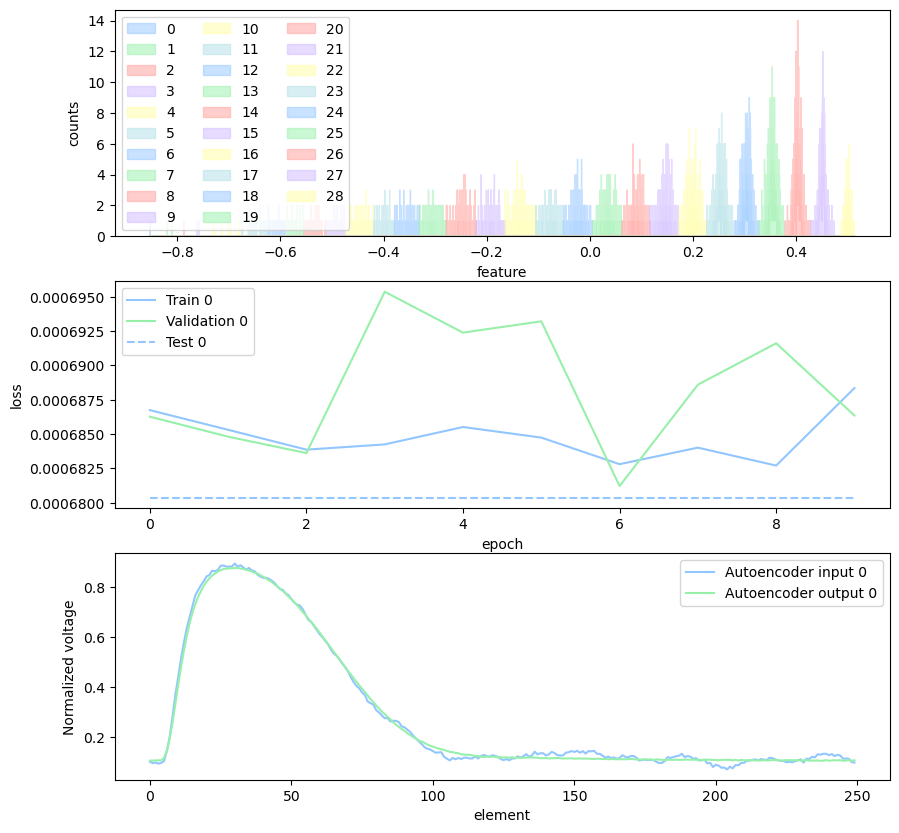

In [8]:
load_run_results("AutoencoderLog/run-2023-10-10-09-19", bw=[0.01])

### Load Sweep

In [9]:
#load_sweep_results("TripletMSE 6", ["alpha", "epochs"])